ANOMALY DETECTION

In [1]:
import numpy as np
import pandas as pd

In [2]:
train = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/train.parquet")
test  = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/test.parquet")

In [3]:
train.head()


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [4]:
train.describe()


,Date,X1,X2,X3,X4,X5
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00
std,NaN,1.391992e-01,1.342811e-02,2.346156e+35,5.812988e+31,1.304814e+00


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


In [6]:
test.head()

,ID,Date,X1,X2,X3,X4,X5
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409856 entries, 0 to 409855
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ID      409856 non-null  int64         
 1   Date    409856 non-null  datetime64[ns]
 2   X1      409856 non-null  float64       
 3   X2      409856 non-null  float64       
 4   X3      409856 non-null  float64       
 5   X4      409856 non-null  float64       
 6   X5      409856 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 21.9 MB


In [8]:
test.describe()

,ID,Date,X1,X2,X3,X4,X5
count,409856.000000,409856,409856.000000,409856.000000,4.098560e+05,4.098560e+05,409856.000000
mean,204927.500000,2022-12-03 08:15:48.485321216,1.139317,5.488174,1.544527e+32,4.857705e+29,1.190927
min,0.000000,2020-12-16 00:00:00,1.000000,5.415434,1.000000e+00,1.000000e+00,0.000000
25%,102463.750000,2021-12-10 00:00:00,1.049171,5.480556,1.000000e+00,1.000000e+00,0.000000
50%,204927.500000,2022-11-30 00:00:00,1.105171,5.488979,1.000000e+00,1.000000e+00,0.693147
75%,307391.250000,2023-11-23 00:00:00,1.214096,5.496717,1.000000e+00,2.718282e+00,2.890372
max,409855.000000,2024-12-11 00:00:00,3.455613,5.539890,6.076030e+37,5.540622e+34,3.465736
std,118315.380301,NaN,0.138936,0.013439,9.494028e+34,1.036758e+32,1.305848


# Exploratory Data Analysis (EDA)

EDA helps us to understand the data more thoroughly with the plotting of graphs

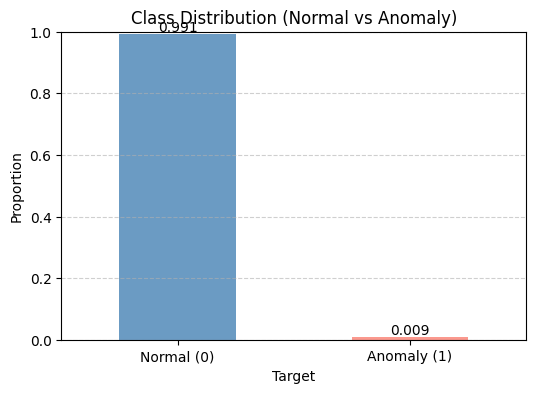

In [9]:
import matplotlib.pyplot as plt

class_counts = train['target'].value_counts(normalize=True)

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['steelblue', 'salmon'], alpha=0.8)

plt.title("Class Distribution (Normal vs Anomaly)")
plt.xticks([0,1], ['Normal (0)', 'Anomaly (1)'], rotation=0)
plt.ylabel("Proportion")
plt.xlabel("Target")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.show()

As you can see in the above bar graph how much class imbalance is there

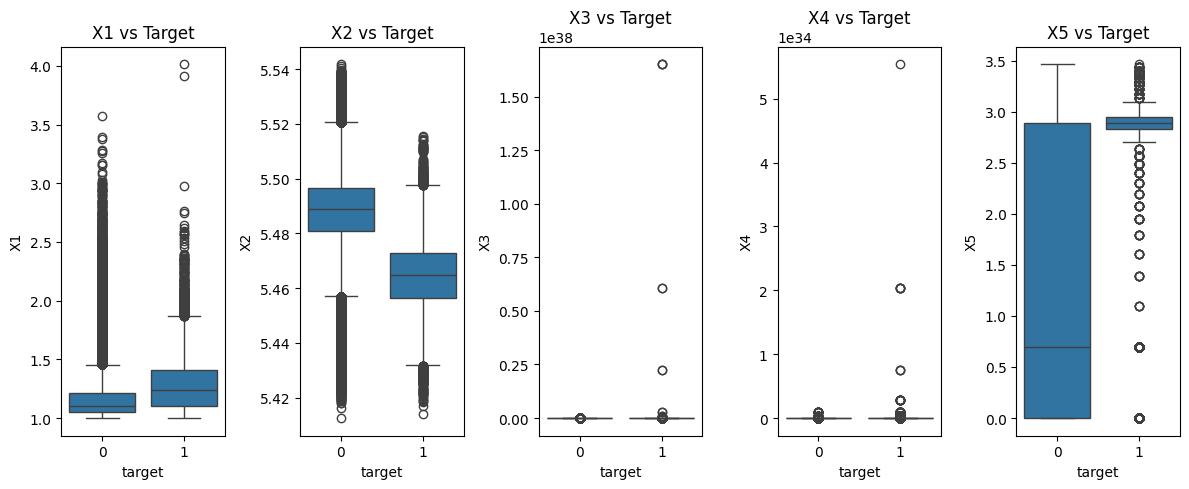

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 5))
for i, col in enumerate(['X1','X2', 'X3', 'X4', 'X5'], 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=train, x='target', y=col)
    plt.title(f'{col} vs Target')
plt.tight_layout()
plt.show()

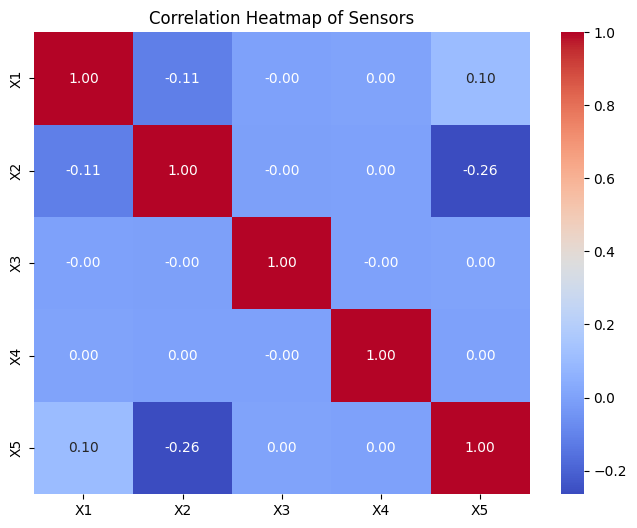

In [11]:
plt.figure(figsize=(8, 6))
corr = train[['X1','X2','X3','X4','X5']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Sensors')
plt.show()

# MODEL

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix,
    precision_score, recall_score
)

import lightgbm as lgb
from xgboost import XGBClassifier

# DATASET LOADING

In [13]:
train["target"] = train["target"].astype(int)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

# Store original test IDs (original order)
if "ID" in test.columns:
    test_ids = test["ID"].copy()
else:
    test_ids = pd.Series(np.arange(len(test)))

Train shape: (1639424, 7)
Test shape : (409856, 7)


# FEATURE ENGINEERING

In [14]:
def make_features(df: pd.DataFrame, sort_by_date=True) -> pd.DataFrame:
    df = df.copy()

    # Convert + sort by Date BEFORE rolling/lag (important)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        if sort_by_date:
            df = df.sort_values("Date").reset_index(drop=True)

        # Date features (hour removed)
        df["day"]     = df["Date"].dt.day
        df["weekday"] = df["Date"].dt.weekday
        df["month"]   = df["Date"].dt.month

    # Sensor columns
    sensor_cols = [c for c in df.columns if c.startswith("X")]
    sensor_cols = [c for c in sensor_cols if c not in ["target", "ID"]]

    df["X_sum"]   = df[sensor_cols].sum(axis=1)
    df["X_mean"]  = df[sensor_cols].mean(axis=1)
    df["X_std"]   = df[sensor_cols].std(axis=1)
    df["X_max"]   = df[sensor_cols].max(axis=1)
    df["X_min"]   = df[sensor_cols].min(axis=1)
    df["X_range"] = df["X_max"] - df["X_min"]

    for col in sensor_cols:
        df[f"{col}_lag1"]  = df[col].shift(1)
        df[f"{col}_lag2"]  = df[col].shift(2)
        df[f"{col}_lag3"]  = df[col].shift(3)
        df[f"{col}_diff1"] = df[col] - df[f"{col}_lag1"]
        df[f"{col}_diff2"] = df[col] - df[f"{col}_lag2"]
        df[f"{col}_diff3"] = df[col] - df[f"{col}_lag3"]

    windows = [3, 5, 10, 20]
    for col in sensor_cols:
        for w in windows:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(w, min_periods=1).std()
            df[f"{col}_roll_min_{w}"]  = df[col].rolling(w, min_periods=1).min()
            df[f"{col}_roll_max_{w}"]  = df[col].rolling(w, min_periods=1).max()

        df[f"{col}_ema_5"]  = df[col].ewm(span=5, adjust=False).mean()
        df[f"{col}_ema_10"] = df[col].ewm(span=10, adjust=False).mean()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)

    if "Date" in df.columns:
        df.drop(columns=["Date"], inplace=True)

    return df

train_fe = make_features(train, sort_by_date=True)

test_fe  = make_features(test, sort_by_date=True)

print("Train FE:", train_fe.shape)
print("Test FE :", test_fe.shape)

/tmp/ipykernel_24/1063206243.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_mean_{w}"] = df[col].rolling(w, min_periods=1).mean()
/tmp/ipykernel_24/1063206243.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_std_{w}"]  = df[col].rolling(w, min_periods=1).std()
/tmp/ipykernel_24/1063206243.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

Train FE: (1639424, 135)
Test FE : (409856, 135)


# PREPARING FEATURE

In [15]:
drop_cols = ["target"]
if "ID" in train_fe.columns:
    drop_cols.append("ID")

X = train_fe.drop(columns=drop_cols)
y = train_fe["target"].astype(int)

feature_cols = X.columns
X_test = test_fe[feature_cols].copy()

print("Final feature count:", X.shape[1])

Final feature count: 134


# TRAIN/VAL SPLIT

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
base_spw = neg / max(pos, 1)

print("Class balance:")
print("Normal:", neg, "Anomaly:", pos)
print("Base scale_pos_weight:", base_spw)

Class balance:
Normal: 1300309 Anomaly: 11230
Base scale_pos_weight: 115.78886910062333


# TUNE WEIGHTS

In [17]:
multipliers = [1.0]
tune_results = []

for m in multipliers:
    spw = base_spw * m

    print(f"Training LGBM with scale_pos_weight x{m} => {spw:.2f}")

    temp_lgb = lgb.LGBMClassifier(
        n_estimators=2500,
        learning_rate=0.02,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=30,
        reg_lambda=2.0,
        scale_pos_weight=spw,
        random_state=42
    )

    temp_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="binary_logloss",
        callbacks=[lgb.log_evaluation(period=300)]
    )

    val_prob = temp_lgb.predict_proba(X_val)[:, 1]
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.99, 300):
        pred = (val_prob >= t).astype(int)
        f1 = f1_score(y_val, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    val_pred = (val_prob >= best_t).astype(int)
    p1 = precision_score(y_val, val_pred, pos_label=1, zero_division=0)
    r1 = recall_score(y_val, val_pred, pos_label=1, zero_division=0)

    print(f"Best Threshold: {best_t:.4f}")
    print(f"F1: {best_f1:.6f} | Precision(1): {p1:.4f} | Recall(1): {r1:.4f}")

    tune_results.append((m, spw, best_t, best_f1, p1, r1))

best_setting = max(tune_results, key=lambda x: x[3])
best_m, best_spw, best_lgb_t, best_lgb_f1, best_p1, best_r1 = best_setting

print(f"multiplier: {best_m}")
print(f"scale_pos_weight: {best_spw:.2f}")
print(f"best threshold: {best_lgb_t:.4f}")
print(f"best F1: {best_lgb_f1:.6f}")
print(f"precision(1): {best_p1:.4f}")
print(f"recall(1): {best_r1:.4f}")

Training LGBM with scale_pos_weight x1.0 => 115.79
[LightGBM] [Info] Number of positive: 11230, number of negative: 1300309
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.635819 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25797
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 134
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.008562 -> initscore=-4.751768
[LightGBM] [Info] Start training from score -4.751768
[300]	valid_0's binary_logloss: 0.0665031
[600]	valid_0's binary_logloss: 0.0463912
[900]	valid_0's binary_logloss: 0.0361565
[1200]	valid_0's binary_logloss: 0.0295514
[1500]	valid_0's binary_logloss: 0.024736
[1800]	valid_0's binary_logloss: 0.0213846
[2100]	valid_0's binary_logloss: 0.0187776
[2400]	valid_0's binary_logloss: 0.0167559
Best Threshold: 0.8737
F1: 0.816327 | Precision(1): 0.8358 | Recall(1): 0.7977
multiplier: 1.0
scale_pos_weig

# TRAIN FINAL LGBM + XGB WITH BEST SPW


In [18]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=30,
    reg_lambda=2.0,
    scale_pos_weight=best_spw,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.log_evaluation(period=300)]
)

print("Training FINAL XGBoost")
xgb_model = XGBClassifier(
    n_estimators=2000,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    scale_pos_weight=best_spw,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=300
)



[LightGBM] [Info] Number of positive: 11230, number of negative: 1300309
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.841983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25797
[LightGBM] [Info] Number of data points in the train set: 1311539, number of used features: 134
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.008562 -> initscore=-4.751768
[LightGBM] [Info] Start training from score -4.751768
[300]	valid_0's binary_logloss: 0.0665031
[600]	valid_0's binary_logloss: 0.0463912
[900]	valid_0's binary_logloss: 0.0361565
[1200]	valid_0's binary_logloss: 0.0295514
[1500]	valid_0's binary_logloss: 0.024736
[1800]	valid_0's binary_logloss: 0.0213846
[2100]	valid_0's binary_logloss: 0.0187776
[2400]	valid_0's binary_logloss: 0.0167559
[2700]	valid_0's binary_logloss: 0.0152877
[3000]	valid_0's binary_logloss: 0.0140837
Training FINAL XGBoost
[0]	validation_0-logloss:0.66767
[300]	validation_0

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, num_parallel_tree=None, ...)

# ENSEMBLE + THRESHOLD TUNING


In [19]:
lgb_val_prob  = lgb_model.predict_proba(X_val)[:, 1]
xgb_val_prob  = xgb_model.predict_proba(X_val)[:, 1]

lgb_test_prob = lgb_model.predict_proba(X_test)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

weights = [(0.7,0.3),(0.6,0.4),(0.5,0.5),(0.4,0.6)]
best_f1 = -1
best_w = None
best_t = None

for wl, wx in weights:
    val_prob = wl*lgb_val_prob + wx*xgb_val_prob

    for t in np.linspace(0.05, 0.99, 300):
        pred = (val_prob >= t).astype(int)
        f1 = f1_score(y_val, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_w = (wl, wx)
            best_t = t

print("BEST ENSEMBLE FOUND:")
print("Weights (LGBM, XGB):", best_w)
print("Best Threshold:", best_t)
print("Best F1:", best_f1)
# Final validation evaluation
wl, wx = best_w
val_prob_final = wl*lgb_val_prob + wx*xgb_val_prob
val_pred_final = (val_prob_final >= best_t).astype(int)

print("Accuracy:", accuracy_score(y_val, val_pred_final))
print("F1 Score :", f1_score(y_val, val_pred_final))
print("\nClassification Report:\n", classification_report(y_val, val_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_pred_final))

BEST ENSEMBLE FOUND:
Weights (LGBM, XGB): (0.6, 0.4)
Best Threshold: 0.864247491638796
Best F1: 0.821502153961416
Accuracy: 0.9970934931454626
F1 Score : 0.821502153961416

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    325077
           1       0.87      0.78      0.82      2808

    accuracy                           1.00    327885
   macro avg       0.93      0.89      0.91    327885
weighted avg       1.00      1.00      1.00    327885


Confusion Matrix:
 [[324739    338]
 [   615   2193]]


# FINAL TEST PREDICTION + SUBMISSION FILE


In [20]:
test_prob_final = wl*lgb_test_prob + wx*xgb_test_prob
test_pred_sorted = (test_prob_final >= best_t).astype(int)

test_raw = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/test.parquet")

original_ids = test_raw["ID"].values

test_sorted = test_raw.copy()
test_sorted["Date"] = pd.to_datetime(test_sorted["Date"], errors="coerce")
test_sorted = test_sorted.sort_values("Date").reset_index(drop=True)

sorted_ids = test_sorted["ID"].values

pred_map = pd.DataFrame({
    "ID": sorted_ids,
    "target": test_pred_sorted
})
submission_fixed = pred_map.set_index("ID").loc[original_ids].reset_index()

sample = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/sample_submission.parquet")
submission_fixed = submission_fixed[["ID", "target"]]

print("Fixed submission preview:")
print(submission_fixed.head())

submission_fixed.to_csv("submission_FULLYFINAL.csv", index=False)
print("Saved as: submission_FULLYFINAL.csv")

Fixed submission preview:
   ID  target
0   0       0
1   1       0
2   2       0
3   3       0
4   4       0
Saved as: submission_FULLYFINAL.csv
